# Comparison tutorial

In [34]:
import sys
from pathlib import Path

sys.path.insert(
    0,
    str(Path.home() / "GitHub" / "MIML" / "src")
)
output_path = str(Path.home() / "GitHub" / "MIML" / "src" / "miml" / "tutorial")

from miml.data import load_dataset

import miml

print(miml.__file__)

/home/juanjo/GitHub/MIML/src/miml/__init__.py


# Install dependencies

In [35]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Import metrics, classifier and Hausdorff distances

In [36]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
)

# Add the project source directory to Python's path.
sys.path.insert(
    0,
    str(Path.home() / "GitHub" / "MIML" / "src"),
)

from miml.data import load_dataset
from miml.report import Report

from miml.classifier.miml.lazy.miml_br_knn import MIMLBRkNN
from miml.classifier.miml.lazy.miml_dgc import MIMLDGC
from miml.classifier.miml.lazy.miml_map_knn import MIMLMAPkNN
from miml.classifier.miml.lazy.miml_knn import MIMLkNN

from miml.core.average_hausdorff import AverageHausdorff
from miml.core.maximal_hausdorff import MaximalHausdorff
from miml.core.minimal_hausdorff import MinimalHausdorff

# Load datasets

In [37]:
birds = load_dataset(
    "miml_birds.arff",
    from_library=True,
)

birds_train, birds_test = birds.split_dataset(
    train_percentage=0.8,
    seed=7,
)


text = load_dataset(
    "miml_text_data.arff",
    from_library=True,
)

text_train, text_test = text.split_dataset(
    train_percentage=0.8,
    seed=7,
)


image = load_dataset(
    "miml_image_data.arff",
    from_library=True,
)

image_train, image_test = image.split_dataset(
    train_percentage=0.8,
    seed=7,
)

datasets = {
    "birds": (birds_train, birds_test),
    "text": (text_train, text_test),
    "image": (image_train, image_test),
}

# Add Algorithms and distances to list

In [38]:
algorithms = {
    "MIMLBRkNN": MIMLBRkNN,
    "MIMLDGC": MIMLDGC,
    "MIMLMAPkNN": MIMLMAPkNN,
    "MIMLkNN": MIMLkNN,
}


distances = {
    "AverageHausdorff": AverageHausdorff(),
    "MaximalHausdorff": MaximalHausdorff(),
    "MinimalHausdorff": MinimalHausdorff(),
}

# Add method to load algorithm

In [39]:
def create_classifiers(metric):
    return {
        "MIMLBRkNN": MIMLBRkNN(
            metric=metric,
            num_of_neighbours=10,
        ),
        "MIMLDGC": MIMLDGC(
            metric=metric,
            num_of_neighbours=10,
        ),
        "MIMLMAPkNN": MIMLMAPkNN(
            metric=metric,
            num_of_neighbours=10,
        ),
        "MIMLkNN": MIMLkNN(
            metric=metric,
            num_references=10,
            num_citers=10,
        ),
    }

In [40]:
def get_true_labels(dataset):
    bags = list(dataset.data.values())

    labels = []

    for bag in bags:
        bag_labels = bag.get_labels()

        if bag_labels.ndim == 2:
            bag_labels = np.max(bag_labels, axis=0)

        labels.append(bag_labels)

    return np.asarray(labels, dtype=int)

In [41]:
def multilabel_accuracy(y_true, y_pred):
    """Calculate accuracy over all individual label decisions."""

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(y_true == y_pred)

In [42]:
def calculate_metrics(y_true, y_pred):
    return {
        "F1 Macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "F1 Micro": f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0,
        ),
        "Subset Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Hamming Loss": hamming_loss(
            y_true,
            y_pred,
        ),
        "Accuracy": multilabel_accuracy(
            y_true,
            y_pred,
        ),
    }

# Run algorithm and save results in table

In [43]:
log_cols=["Algorithm", "Dataset", "Distance", "Subset Accuracy", "Accuracy", "F1 Score Macro", "F1 Score Micro", "Hamming Loss"]
log = pd.DataFrame({
    "Algorithm": pd.Series(dtype="object"),
    "Dataset": pd.Series(dtype="object"),
    "Distance": pd.Series(dtype="object"),
    "Subset Accuracy": pd.Series(dtype="float64"),
    "Accuracy": pd.Series(dtype="float64"),
    "F1 Score Macro": pd.Series(dtype="float64"),
    "F1 Score Micro": pd.Series(dtype="float64"),
    "Hamming Loss": pd.Series(dtype="float64"),
})

for dataset_name, (dataset_train, dataset_test) in datasets.items():

    for distance_name, distance in distances.items():

        classifiers = create_classifiers(distance)

        for classifier_name, classifier in classifiers.items():

            classifier.build(dataset_train)
            y_pred = classifier.evaluate(dataset_test)
            probs = classifier.predict_proba(dataset_test)

            report = Report(y_pred, probs, dataset_test)
            report.calculate_metrics()    
            log_entry = pd.DataFrame([[classifier_name, dataset_name, distance_name, report.metrics_value["subset-accuracy-score"], report.metrics_value["accuracy-score"], report.metrics_value["f1-score-macro"], report.metrics_value["f1-score-micro"], report.metrics_value["hamming-loss"]]], columns=log_cols)
            log = pd.concat([log, log_entry], ignore_index=True)

# Show results

In [44]:
results_df = pd.DataFrame(log)
results_df

,Algorithm,Dataset,Distance,Subset Accuracy,Accuracy,F1 Score Macro,F1 Score Micro,Hamming Loss
0,MIMLBRkNN,birds,AverageHausdorff,0.058824,0.110131,0.043499,0.164179,0.115583
1,MIMLDGC,birds,AverageHausdorff,0.058824,0.110131,0.048543,0.174603,0.107327
2,MIMLMAPkNN,birds,AverageHausdorff,0.000000,0.019608,0.016869,0.038095,0.104231
3,MIMLkNN,birds,AverageHausdorff,0.000000,0.016340,0.019737,0.056075,0.104231
4,MIMLBRkNN,birds,MaximalHausdorff,0.078431,0.166340,0.055528,0.213836,0.128999
5,MIMLDGC,birds,MaximalHausdorff,0.098039,0.170588,0.074417,0.214765,0.120743
6,MIMLMAPkNN,birds,MaximalHausdorff,0.019608,0.019608,0.005540,0.019231,0.105263
7,MIMLkNN,birds,MaximalHausdorff,0.019608,0.019608,0.008772,0.019417,0.104231
8,MIMLBRkNN,birds,MinimalHausdorff,0.117647,0.208170,0.101590,0.260274,0.111455
9,MIMLDGC,birds,MinimalHausdorff,0.117647,0.226144,0.124115,0.278146,0.112487


In [50]:
results_df.round(4)

,Algorithm,Dataset,Distance,Subset Accuracy,Accuracy,F1 Score Macro,F1 Score Micro,Hamming Loss
0,MIMLBRkNN,birds,AverageHausdorff,0.0588,0.1101,0.0435,0.1642,0.1156
1,MIMLDGC,birds,AverageHausdorff,0.0588,0.1101,0.0485,0.1746,0.1073
2,MIMLMAPkNN,birds,AverageHausdorff,0.0000,0.0196,0.0169,0.0381,0.1042
3,MIMLkNN,birds,AverageHausdorff,0.0000,0.0163,0.0197,0.0561,0.1042
4,MIMLBRkNN,birds,MaximalHausdorff,0.0784,0.1663,0.0555,0.2138,0.1290
5,MIMLDGC,birds,MaximalHausdorff,0.0980,0.1706,0.0744,0.2148,0.1207
6,MIMLMAPkNN,birds,MaximalHausdorff,0.0196,0.0196,0.0055,0.0192,0.1053
7,MIMLkNN,birds,MaximalHausdorff,0.0196,0.0196,0.0088,0.0194,0.1042
8,MIMLBRkNN,birds,MinimalHausdorff,0.1176,0.2082,0.1016,0.2603,0.1115
9,MIMLDGC,birds,MinimalHausdorff,0.1176,0.2261,0.1241,0.2781,0.1125


# Save results in csv file

In [46]:
results_path = Path(output_path) / "miml_experiments.csv"

results_df.to_csv(
    results_path,
    index=False,
)

print(f"Results saved to: {results_path}")

Results saved to: /home/juanjo/GitHub/MIML/src/miml/tutorial/miml_experiments.csv


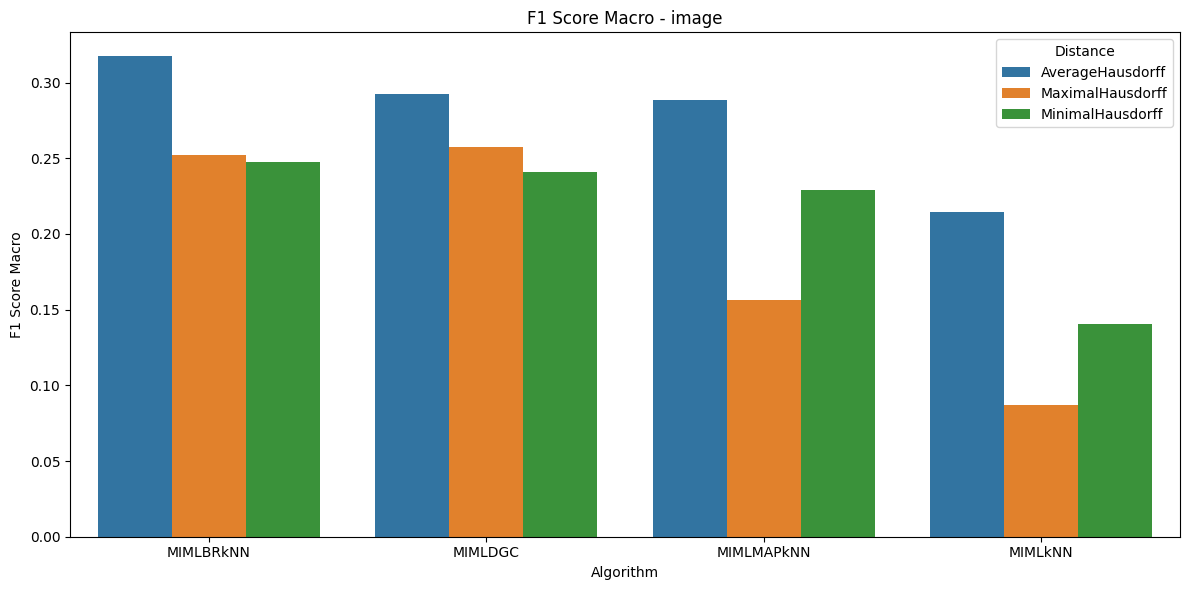

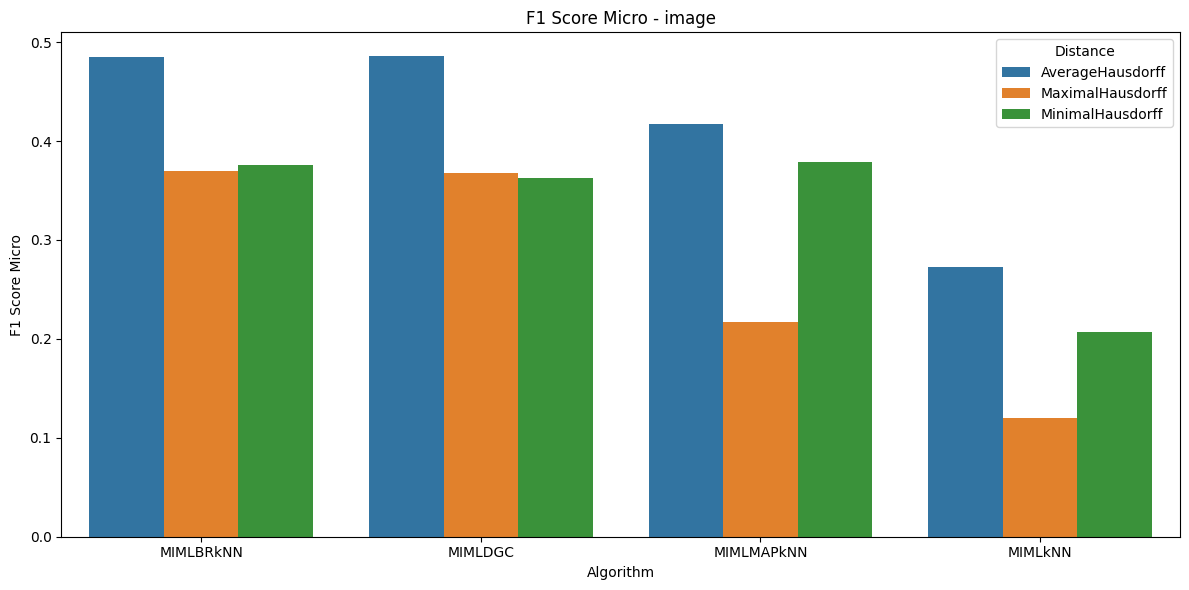

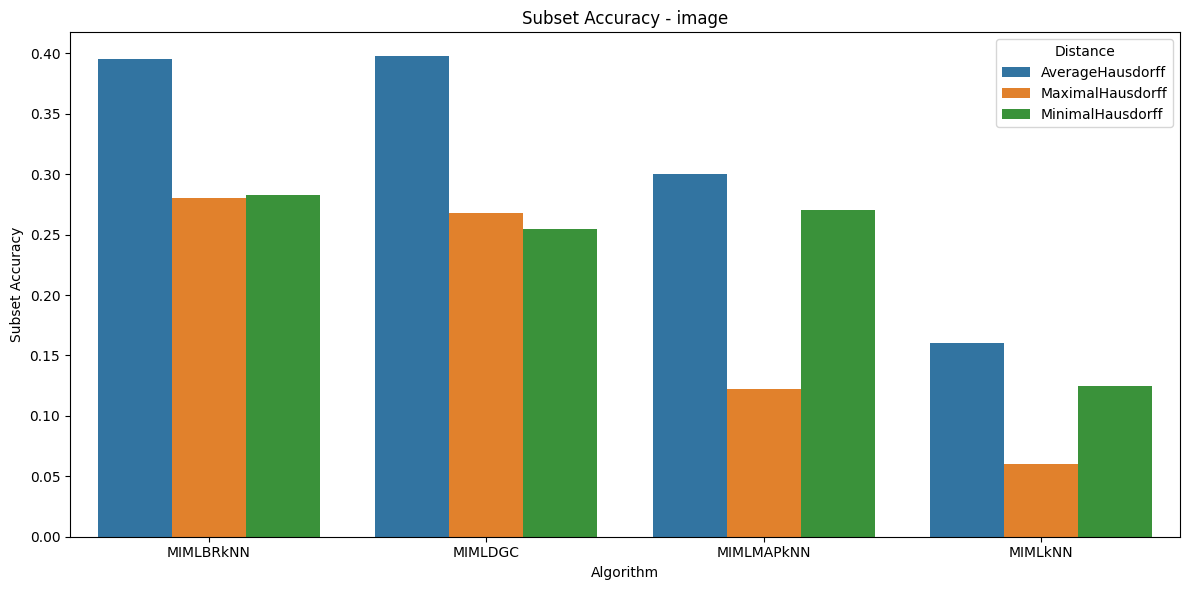

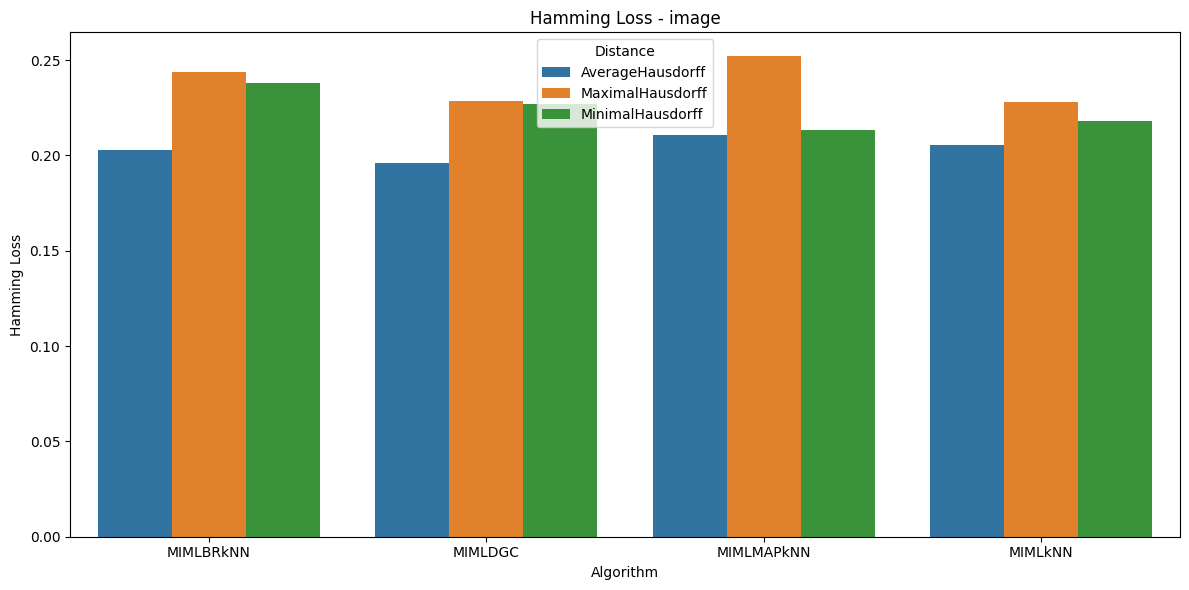

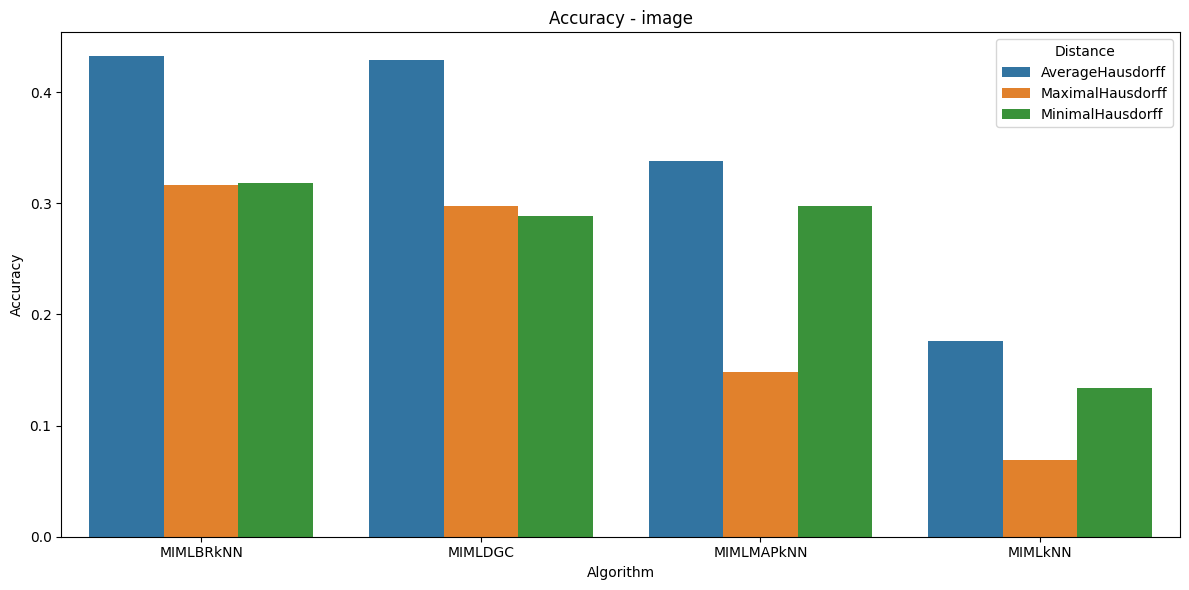

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric(dataframe, metric, dataset_name):

    data = dataframe[
        dataframe["Dataset"] == dataset_name
    ]

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=data,
        x="Algorithm",
        y=metric,
        hue="Distance",
    )

    plt.title(f"{metric} - {dataset_name}")
    plt.xlabel("Algorithm")
    plt.ylabel(metric)

    plt.tight_layout()
    plt.show()


metrics_to_plot = [
    "F1 Score Macro",
    "F1 Score Micro",
    "Subset Accuracy",
    "Hamming Loss",
    "Accuracy",
]

for metric in metrics_to_plot:
    plot_metric(
        results_df,
        metric,
        dataset_name,
    )

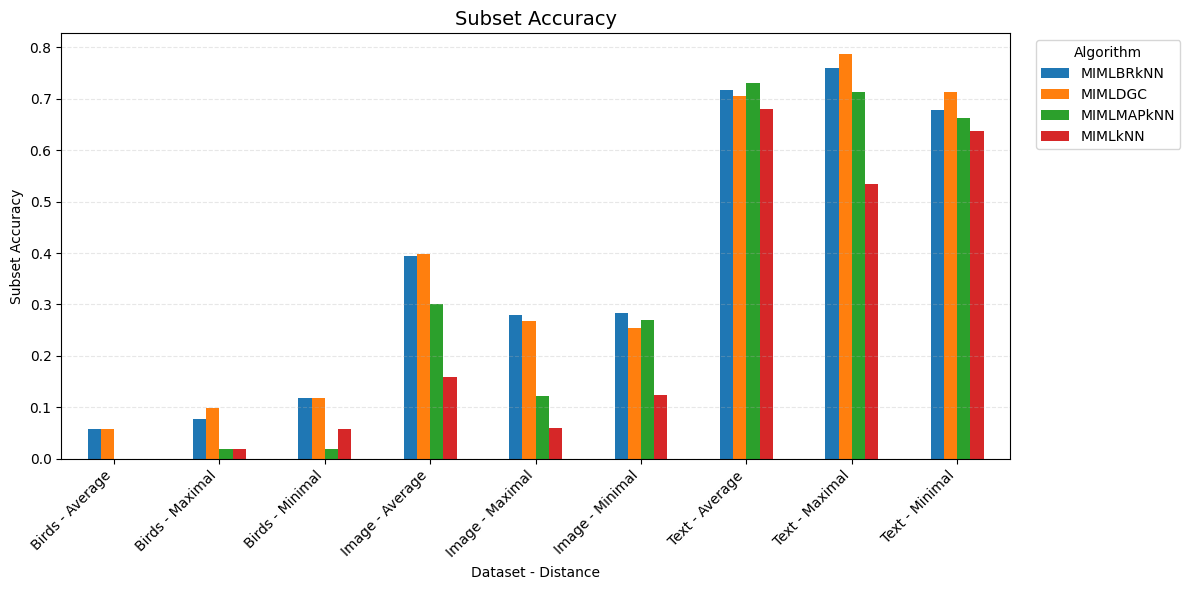

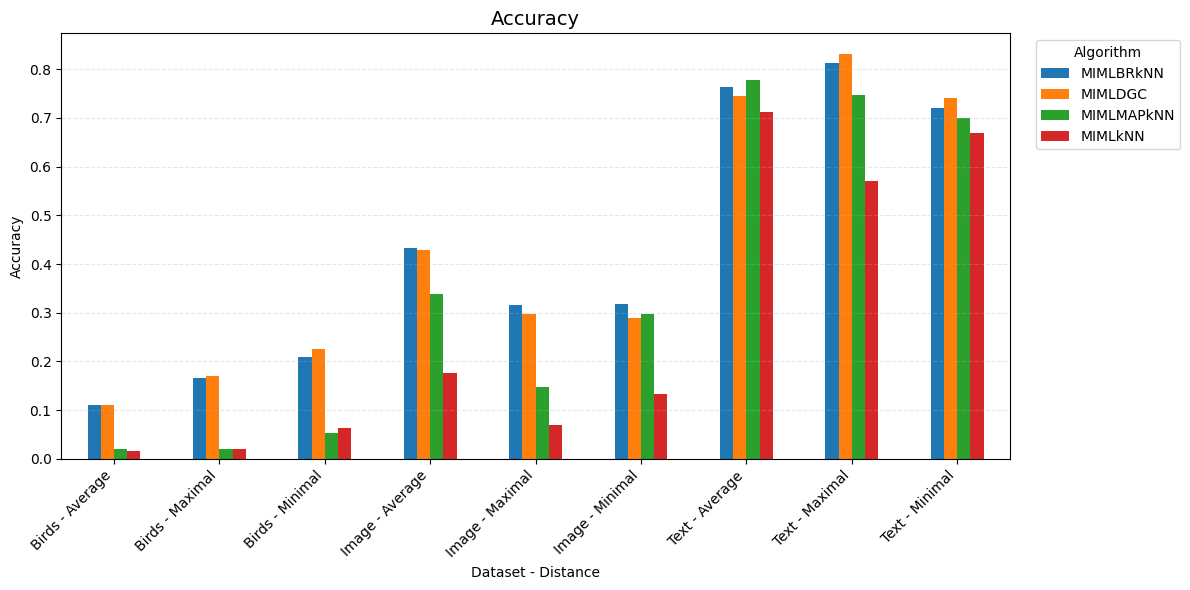

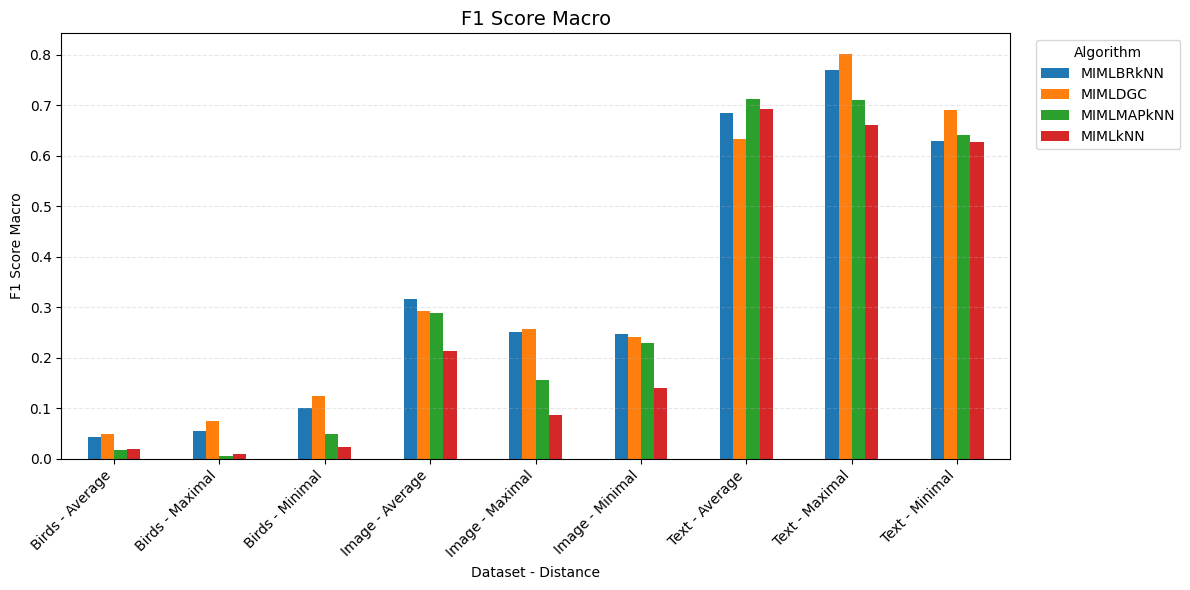

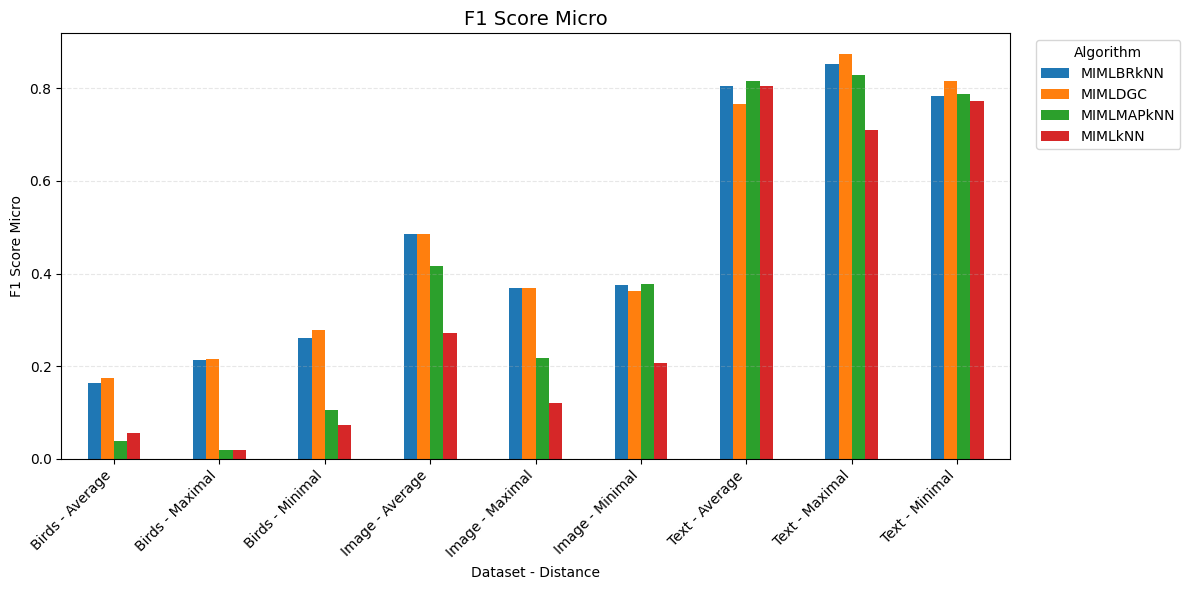

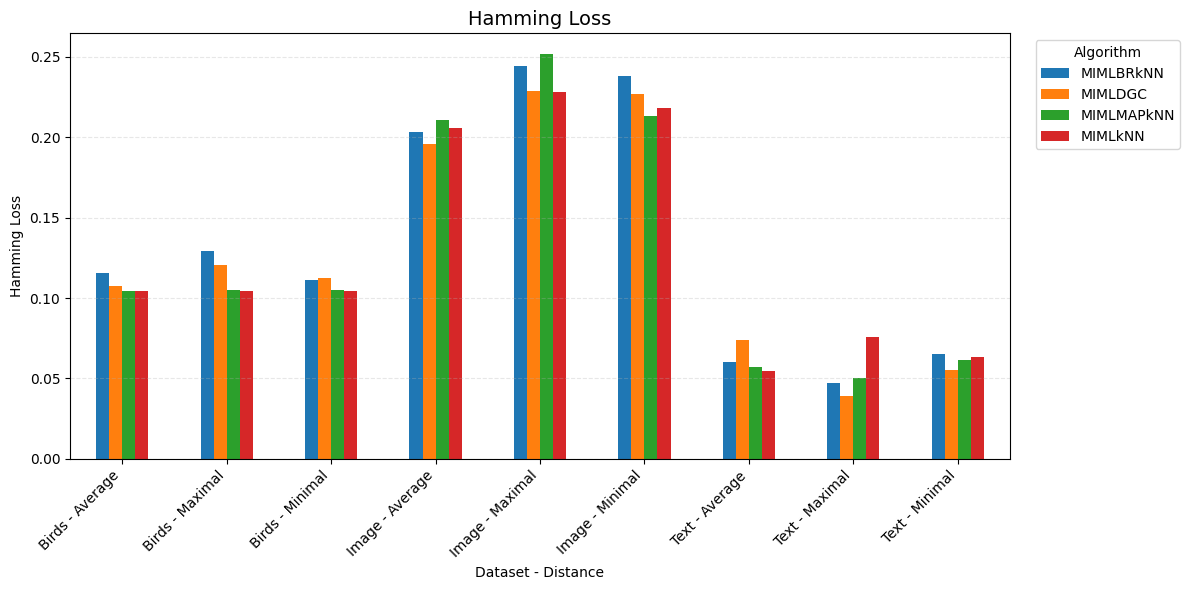

In [52]:
import matplotlib.pyplot as plt


def plot_results_by_metric(df):
    """
    Genera un gráfico para cada métrica de evaluación,
    comparando todos los algoritmos para cada combinación
    de Dataset y Distance.
    """

    metrics = [
        "Subset Accuracy",
        "Accuracy",
        "F1 Score Macro",
        "F1 Score Micro",
        "Hamming Loss"
    ]

    # Obtener los algoritmos
    algorithms = df["Algorithm"].unique()

    # Copia del DataFrame para no modificar el original
    df = df.copy()

    # Crear una etiqueta para cada combinación Dataset + Distance
    df["Experiment"] = (
        df["Dataset"].str.capitalize()
        + " - "
        + df["Distance"].str.replace("Hausdorff", "", regex=False)
    )

    for metric in metrics:

        # Reorganizar los datos
        pivot = df.pivot(
            index="Experiment",
            columns="Algorithm",
            values=metric
        )

        # Mantener el orden original de los algoritmos
        pivot = pivot.reindex(columns=algorithms)

        # Crear gráfico
        ax = pivot.plot(
            kind="bar",
            figsize=(12, 6)
        )

        ax.set_title(metric, fontsize=14)
        ax.set_xlabel("Dataset - Distance")
        ax.set_ylabel(metric)

        # Rotar etiquetas del eje X
        plt.xticks(rotation=45, ha="right")

        # Leyenda
        ax.legend(
            title="Algorithm",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        # Grid horizontal
        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.3
        )

        plt.tight_layout()
        plt.show()

plot_results_by_metric(results_df)